# tokenização e PLN

In [1]:

!pip install transformers torch sentencepiece

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importações
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [3]:
# baixa o modelo treinado para indentificar palavras estisticamente
nltk.download("punkt")
nltk.download("punkt_tab")
#baixar as stpwords
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PROG09\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PROG09\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PROG09\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
texto = "hoje o dia está lindo"

tokens = word_tokenize(texto)

print(tokens)

['hoje', 'o', 'dia', 'está', 'lindo']


# letra de musica 

In [15]:
with open('letras.txt', 'r', encoding='utf-8') as arquivo:
    letras = arquivo.read()

letras = letras.replace(',', '')

tokens = word_tokenize(letras.lower(), language='portuguese')

In [6]:
from nltk import FreqDist
import pandas as pd 

In [7]:
frequencia = FreqDist(tokens)
for i,j in frequencia.items():
    print(f"token: {i:10} | quantidade: {j}")

token: hoje       | quantidade: 1
token: o          | quantidade: 1
token: dia        | quantidade: 1
token: está       | quantidade: 1
token: lindo      | quantidade: 1


In [8]:
df = pd.DataFrame(frequencia.items(),columns=["Palavras","Quantidade"])
df.sort_values("Quantidade", ascending=False)

,Palavras,Quantidade
0,hoje,1
1,o,1
2,dia,1
3,está,1
4,lindo,1


# stopwords

In [9]:
stopwords_pt = stopwords.words("portuguese")
len(stopwords_pt)

207

In [10]:
tokens_sem_stopwords = [
    palavra for palavra in tokens
    if palavra not in stopwords_pt
]
len(tokens_sem_stopwords)

3

In [11]:
frequencia2 = FreqDist(tokens_sem_stopwords)
df2 = pd.DataFrame(frequencia2.items(),columns=["Palavras","Quantidade"])
df2.sort_values("Quantidade", ascending=False)

,Palavras,Quantidade
0,hoje,1
1,dia,1
2,lindo,1


 # string da letra simplidicada

In [12]:
# Cria uma string da letra sem as stopwords
letras_simplificada = ''
for i in tokens_sem_stopwords:
    letras_simplificada += ' ' + i

In [ ]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


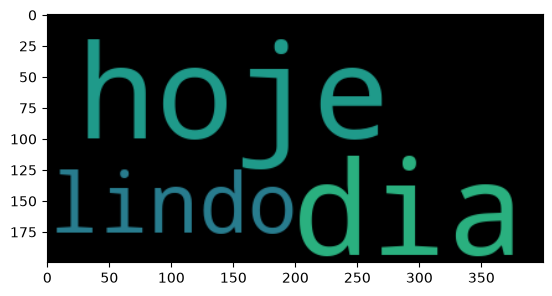

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(stopwords=stopwords_pt).generate(letras_simplificada)
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

# analizando o senttimento da letra 

In [ ]:
from transformers import pipeline

classificador = pipeline(
    "sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)

letra_simplificada = letra_simplificada[letra_simplificada]

sentimento = classificador(letra_simplificada)
print(sentimento)